In [1]:
!pip install tqdm langid matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import sqlite3
import pandas as pd
from langdetect import detect, LangDetectException
from tqdm.notebook import tqdm

In [3]:
conn = sqlite3.connect('../../data/all_tweets.db')

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print("📋 Tables in the database:")
print(tables)

conn.close()


📋 Tables in the database:
       name
0    tweets
1  hashtags


In [4]:
conn = sqlite3.connect('../../data/all_tweets.db')
tweets_columns = pd.read_sql_query("PRAGMA table_info(tweets);", conn)
print("🧾 Columns in 'tweets':")
print(tweets_columns[['cid', 'name', 'type']])

🧾 Columns in 'tweets':
   cid        name     type
0    0          id     TEXT
1    1        user     TEXT
2    2       tweet     TEXT
3    3       likes  INTEGER
4    4    retweets  INTEGER
5    5     replies  INTEGER
6    6      quotes  INTEGER
7    7  clean_text     TEXT


In [5]:
hashtags_columns = pd.read_sql_query("PRAGMA table_info(hashtags);", conn)
print("\n🏷️ Columns in 'hashtags':")
print(hashtags_columns[['cid', 'name', 'type']])





🏷️ Columns in 'hashtags':
   cid                   name     type
0    0               tweet_id     TEXT
1    1               hashtags     TEXT
2    2  text_without_hashtags     TEXT
3    3                  likes  INTEGER
4    4               retweets  INTEGER
5    5                replies  INTEGER
6    6                 quotes  INTEGER


In [6]:
pd.read_sql_query("SELECT * FROM tweets LIMIT 5;", conn)

,id,user,tweet,likes,retweets,replies,quotes,clean_text
0,1633518817476321299,MarketOne_Intl,Are you struggling to turn your #B2B account-b...,3,1,0,0,Are you struggling to turn your #B2B account-b...
1,1606666027252719616,MarketOne_Intl,"Wishing all our clients, partners and colleagu...",0,0,0,0,"Wishing all our clients, partners and colleagu..."
2,1572643083279388673,MarketOne_Intl,"So you've built your #ABM target account list,...",0,0,0,0,"So you've built your #ABM target account list,..."
3,1565372152945278978,MarketOne_Intl,Is your #Salesdevelopment team in-house or out...,1,1,0,1,Is your #Salesdevelopment team in-house or out...
4,1562786915916849152,MarketOne_Intl,Is your sales team 'cherry picking' leads? Her...,0,1,0,0,Is your sales team 'cherry picking' leads? Her...


In [7]:
pd.read_sql_query("SELECT * FROM hashtags LIMIT 5;", conn)

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes
0,1000000010413539328,,Leadership comes from your Heart. How to Lead ...,0,0,0,0
1,1000000018231844864,,Jij hebt geen slakken 😑,0,0,1,0
2,1000000038628724736,,No te preocupes la segunda parte te la enseñam...,74,12,0,1
3,1000000062217334786,,6/15(金)代官山LOOPでの「仮谷お客様感謝デー」ライブより！ 仮谷せいらライブ会場限定...,73,37,2,2
4,1000000086296817664,,ありがとうございます😊 いつでもお待ちしてます(`･ω･´)ゞ,1,0,0,0


In [8]:
conn.close()

In [9]:
# Connect and load first 1 million tweets (with non-null tweet text if needed)
conn = sqlite3.connect('../../data/all_tweets.db')

query = """
SELECT * FROM hashtags
WHERE hashtags IS NOT NULL
LIMIT 25000000
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"Loaded {len(df)} tweets.")
df.head()


Loaded 9850000 tweets.


,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes
0,1000000010413539328,,Leadership comes from your Heart. How to Lead ...,0,0,0,0
1,1000000018231844864,,Jij hebt geen slakken 😑,0,0,1,0
2,1000000038628724736,,No te preocupes la segunda parte te la enseñam...,74,12,0,1
3,1000000062217334786,,6/15(金)代官山LOOPでの「仮谷お客様感謝デー」ライブより！ 仮谷せいらライブ会場限定...,73,37,2,2
4,1000000086296817664,,ありがとうございます😊 いつでもお待ちしてます(`･ω･´)ゞ,1,0,0,0


In [10]:
df

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes
0,1000000010413539328,,Leadership comes from your Heart. How to Lead ...,0,0,0,0
1,1000000018231844864,,Jij hebt geen slakken 😑,0,0,1,0
2,1000000038628724736,,No te preocupes la segunda parte te la enseñam...,74,12,0,1
3,1000000062217334786,,6/15(金)代官山LOOPでの「仮谷お客様感謝デー」ライブより！ 仮谷せいらライブ会場限定...,73,37,2,2
4,1000000086296817664,,ありがとうございます😊 いつでもお待ちしてます(`･ω･´)ゞ,1,0,0,0
...,...,...,...,...,...,...,...
9849995,1241474952085278726,"worldpoetryday,acceptance,love","On this , let's create and",2,2,0,0
9849996,1241474965708378119,,Veig que no m’he perdut res del discurs de .,9,0,1,0
9849997,1241475025267458049,,If anyone can lighten our world right now it’s !,325,46,6,6
9849998,1241475030166495234,TestMasivosYa,"Mira , acá esta el video de los test disponibl...",0,0,1,0


In [11]:
import numpy as np

# Convert empty or whitespace-only strings to NaN
df['hashtags'] = df['hashtags'].replace(r'^\s*$', np.nan, regex=True)

# Drop rows where hashtags is now NaN
df = df[df['hashtags'].notna()]


In [12]:
df

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes
6,1000000100339453954,AkashicIntegrationBlog,I realized that even though I was keeping trac...,0,0,0,0
15,1000000314907484161,business,The traits that drive startup founders forward...,0,0,0,0
17,1000000359136448512,"multimedia,video,web,print,audio,podcasts,webs...",Happy Memorial Day Weekend! #multimedia #video...,0,0,0,0
18,1000000372650409985,"CannesLions,onup",Looking forward to Susan Johnson David Oyelowo...,6,4,1,0
21,1000000433786703872,HOBYMD2018,We couldn't do our seminar without the amazing...,4,0,0,0
...,...,...,...,...,...,...,...
9849980,1241474749466722304,"JaredLetoCinemaClub,ferrisbuellersdayoff",Everyone join me in wishing Matthew Broderick ...,573,65,117,11
9849991,1241474917612347399,"diybio,PIHomeLab",Still some work to do (like adding safety feat...,25,1,0,0
9849992,1241474919839473666,"CoronavirusPandemic,xbox,GhostRecon",Not going to lie. I haven't turned on my Xbox ...,0,0,0,0
9849995,1241474952085278726,"worldpoetryday,acceptance,love","On this , let's create and",2,2,0,0


In [13]:
import langid

def is_english_langid(text):
    try:
        lang, _ = langid.classify(text)
        return lang == 'en'
    except Exception:
        return False

In [14]:
from tqdm import tqdm
tqdm.pandas(desc="LangID Detection")
df['is_english'] = df['text_without_hashtags'].astype(str).progress_apply(is_english_langid)

LangID Detection: 100%|█████████████| 3230846/3230846 [27:05<00:00, 1988.20it/s]
/var/folders/wc/khxb4zsj41g41ycbv7f_3fr00000gn/T/ipykernel_66382/3877266657.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_english'] = df['text_without_hashtags'].astype(str).progress_apply(is_english_langid)


In [15]:
english_df = df[df['is_english'] == True].drop(columns=['is_english'])

In [16]:
english_df

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes
6,1000000100339453954,AkashicIntegrationBlog,I realized that even though I was keeping trac...,0,0,0,0
15,1000000314907484161,business,The traits that drive startup founders forward...,0,0,0,0
18,1000000372650409985,"CannesLions,onup",Looking forward to Susan Johnson David Oyelowo...,6,4,1,0
21,1000000433786703872,HOBYMD2018,We couldn't do our seminar without the amazing...,4,0,0,0
24,1000000527168516097,"JENNIE,BLACKPINK",V Live #JENNIE #BLACKPINK,164,87,1,4
...,...,...,...,...,...,...,...
9849978,1241474714272509952,"standupcomedy,comedy",The difference between sex and politics...,0,0,0,0
9849980,1241474749466722304,"JaredLetoCinemaClub,ferrisbuellersdayoff",Everyone join me in wishing Matthew Broderick ...,573,65,117,11
9849991,1241474917612347399,"diybio,PIHomeLab",Still some work to do (like adding safety feat...,25,1,0,0
9849992,1241474919839473666,"CoronavirusPandemic,xbox,GhostRecon",Not going to lie. I haven't turned on my Xbox ...,0,0,0,0


In [17]:
# Save to SQLite DB
new_conn = sqlite3.connect('../../data/25M_all_tweets.sqlite3')
english_df.to_sql('tweets', new_conn, index=False, if_exists='replace')
new_conn.close()

print("✅ Saved to '../../data/25M_all_tweets.sqlite3'")

✅ Saved to '../../data/25M_all_tweets.sqlite3'


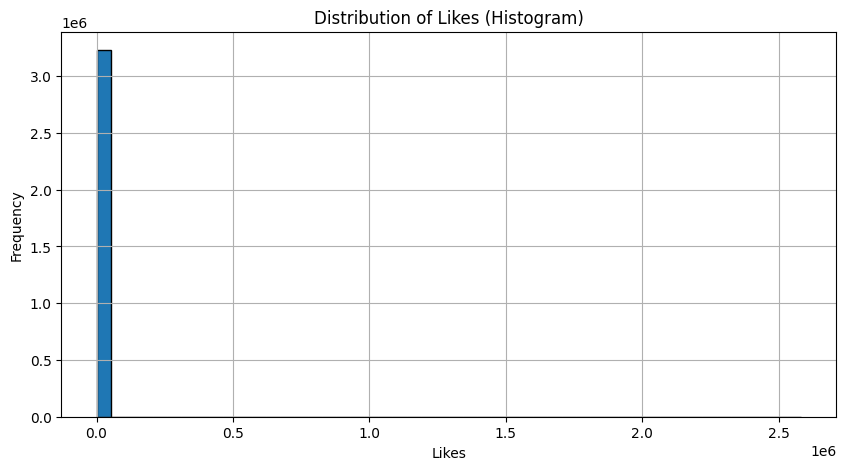

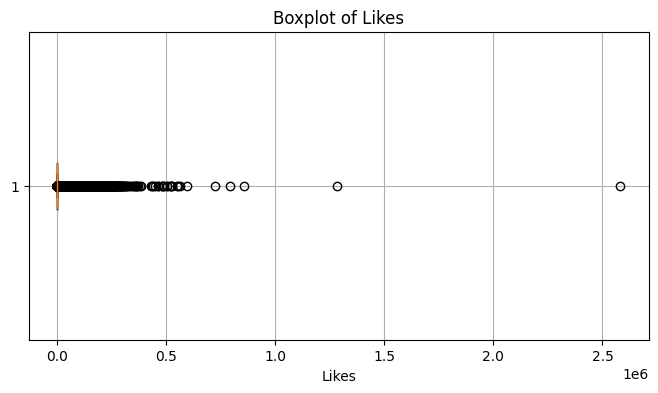

In [18]:
import matplotlib.pyplot as plt

# Plot Histogram
plt.figure(figsize=(10, 5))
plt.hist(df['likes'], bins=50, edgecolor='black')
plt.title('Distribution of Likes (Histogram)')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(df['likes'], vert=False)
plt.title('Boxplot of Likes')
plt.xlabel('Likes')
plt.grid(True)
plt.show()